## 📊 Análisis Univariado

### 🔹 Definición
El **análisis univariado** consiste en describir y resumir una variable individual para entender su comportamiento, tendencia y dispersión.

### 🔹 Objetivos
- Conocer la forma de la distribución (simétrica, sesgada, normal, etc.).
- Calcular medidas de tendencia central.
- Calcular medidas de dispersión.
- Identificar valores atípicos (outliers).

### 🔹 Medidas de tendencia central
| Medida | Descripción | Fórmula |
|:--|:--|:--|
| **Media (μ)** | Promedio de los valores | 𝜇 = (Σxᵢ) / n |
| **Mediana** | Valor central que divide el conjunto en dos mitades | — |
| **Moda** | Valor más frecuente | — |

### 🔹 Medidas de dispersión
| Medida | Descripción | Fórmula |
|:--|:--|:--|
| **Varianza (σ²)** | Promedio de las desviaciones cuadradas respecto a la media | σ² = Σ(xᵢ−μ)² / (n−1) |
| **Desviación estándar (σ)** | Raíz cuadrada de la varianza | σ = √σ² |
| **Rango** | Diferencia entre máximo y mínimo | R = max − min |
| **Rango intercuartílico (IQR)** | Diferencia entre el cuartil 3 y cuartil 1 | IQR = Q3 − Q1 |

### 🔹 Outliers (valores atípicos)
Un **outlier** es un valor que se aleja considerablemente de la mayoría.  
Con la regla del IQR:
> Un valor es outlier si está fuera del rango [Q1 − 1.5 × IQR,  Q3 + 1.5 × IQR]

### 🔹 Gráficos típicos del análisis univariado
- **Histograma:** muestra la distribución de frecuencias.  
- **Boxplot:** detecta valores atípicos.  
- **Violinplot:** combina boxplot y densidad.  

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style(style='whitegrid')
sns.set_context(context='notebook')
plt.rcParams['figure.figsize'] = (11, 9.4)

penguin_color = {
    'Adelie': '#ff6602ff',
    'Gentoo': '#0f7175ff',
    'Chinstrap': '#c65dc9ff'
}

penguins_df = sns.load_dataset('penguins')
penguins_df.dropna(inplace=True)
penguins_df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


# 1️⃣ Medidas de tendencia central

In [14]:
variable = 'body_mass_g'
data = penguins_df[variable]
data

,body_mass_g
0,3750.0
1,3800.0
2,3250.0
4,3450.0
5,3650.0
...,...
338,4925.0
340,4850.0
341,5750.0
342,5200.0


In [15]:
mean_val = data.mean()
median_val = data.median()
mode_val = data.mode()[0]

print(f"📊 Medidas de tendencia central de {variable}")
print(f"Media (μ): {mean_val:.2f}")
print(f"Mediana: {median_val:.2f}")
print(f"Moda: {mode_val:.2f}")

📊 Medidas de tendencia central de body_mass_g
Media (μ): 4207.06
Mediana: 4050.00
Moda: 3800.00


# 2️⃣ Medidas de dispersión

In [16]:
variance_val = data.var()
std_val = data.std()
range_val = data.max() - data.min()
q1 = data.quantile(0.25)
q3 = data.quantile(0.75)
iqr = q3 - q1

print(f"\n📈 Medidas de dispersión de {variable}")
print(f"Varianza (σ²): {variance_val:.2f}")
print(f"Desviación estándar (σ): {std_val:.2f}")
print(f"Rango: {range_val:.2f}")
print(f"Rango intercuartílico (IQR): {iqr:.2f}")



📈 Medidas de dispersión de body_mass_g
Varianza (σ²): 648372.49
Desviación estándar (σ): 805.22
Rango: 3600.00
Rango intercuartílico (IQR): 1225.00


# 3️⃣ Identificación de outliers con la regla del IQR

In [17]:
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

outliers = data[(data < limite_inferior) | (data > limite_superior)]

print(f"\n⚠️ Detección de Outliers (Regla del IQR) para {variable}")
print(f"Límite inferior: {limite_inferior:.2f}")
print(f"Límite superior: {limite_superior:.2f}")
print(f"Número de outliers detectados: {len(outliers)}")


⚠️ Detección de Outliers (Regla del IQR) para body_mass_g
Límite inferior: 1712.50
Límite superior: 6612.50
Número de outliers detectados: 0


# 4️⃣ Visualización de la distribución

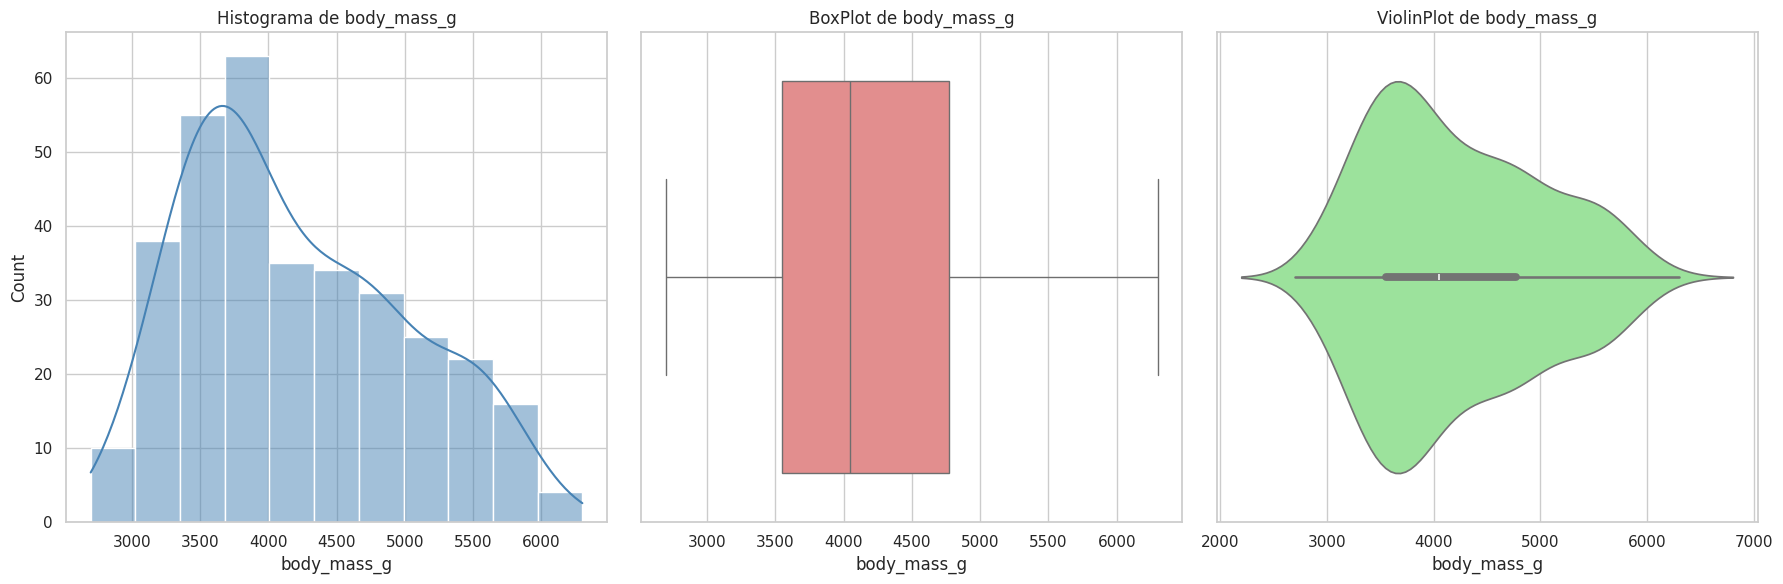

In [18]:
fig,axes = plt.subplots(1,3,figsize=(18,6))

#histograma
sns.histplot(data,kde=True,color='steelblue',ax=axes[0])
axes[0].set_title(f'Histograma de {variable}')

#boxplot
sns.boxplot(x=data,color='lightcoral',ax=axes[1])
axes[1].set_title(f'BoxPlot de {variable}')

#violinplot
sns.violinplot(x=data,color='lightgreen',ax=axes[2])
axes[2].set_title(f'ViolinPlot de {variable}')

plt.tight_layout()
plt.show()

# 5️⃣ Análisis de forma de la distribución

* Asimetría (Skewness): indica si los datos están sesgados a la izquierda o derecha.

* Curtosis (Kurtosis): mide si hay más o menos valores en los extremos comparado con una distribución normal.

In [19]:
from scipy import stats

In [20]:
skew_val = stats.skew(data)
kurt_val = stats.kurtosis(data)

print("\n📉 Forma de la distribución")
print(f"Asimetría (skewness): {skew_val:.3f}")
print(f"Curtosis (kurtosis): {kurt_val:.3f}")


📉 Forma de la distribución
Asimetría (skewness): 0.470
Curtosis (kurtosis): -0.740


In [21]:
# Interpretación básica
if skew_val > 0.5:
    interpretacion = "Distribución sesgada a la derecha (cola larga a la derecha)"
elif skew_val < -0.5:
    interpretacion = "Distribución sesgada a la izquierda (cola larga a la izquierda)"
else:
    interpretacion = "Distribución aproximadamente simétrica"

print(f"🧩 Interpretación: {interpretacion}")

🧩 Interpretación: Distribución aproximadamente simétrica


In [22]:
# Interpretación básica de kurtosis
if kurt_val > 0 :
    interpretacion = "leptocúrtica"
elif kurt_val < 0:
    interpretacion = "platicúrtica"
else:
    interpretacion = "normal"

print(f"🧩 Kurtosis : {interpretacion}")

🧩 Kurtosis : platicúrtica
